In [22]:
import pandas as pd

df = pd.read_csv("../data/ai4i2020.csv")

df.head()


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [23]:
df.shape

(10000, 14)

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [27]:
df["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [28]:
df.nunique()

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Machine failure                2
TWF                            2
HDF                            2
PWF                            2
OSF                            2
RNF                            2
dtype: int64

In [29]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [30]:
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [31]:
pd.crosstab(df["Type"], df["Machine failure"])

Machine failure,0,1
Type,,
H,982,21
L,5765,235
M,2914,83


In [32]:
df.groupby("Type")["Machine failure"].mean() * 100

Type
H    2.093719
L    3.916667
M    2.769436
Name: Machine failure, dtype: float64

In [33]:
df.groupby("Machine failure")[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]"
    ]
].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Machine failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


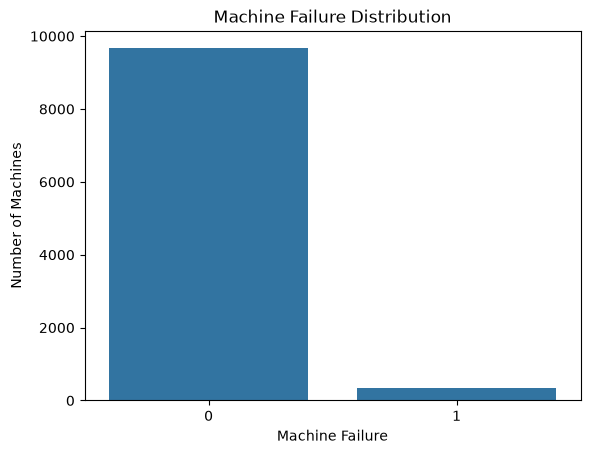

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Machine failure")

plt.title("Machine Failure Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Machines")
plt.show()

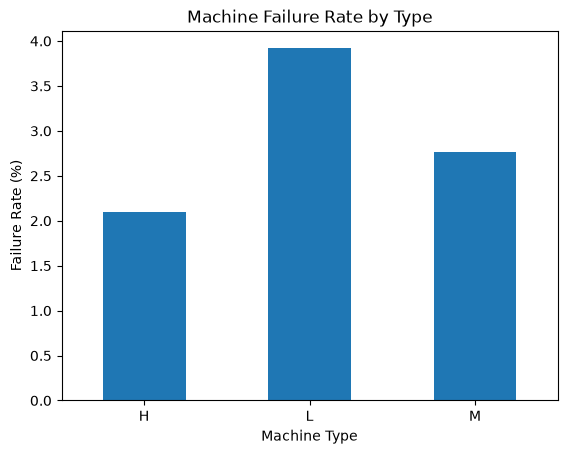

In [35]:
failure_rate = df.groupby("Type")["Machine failure"].mean() * 100

failure_rate.plot(kind="bar")

plt.title("Machine Failure Rate by Type")
plt.xlabel("Machine Type")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=0)
plt.show()

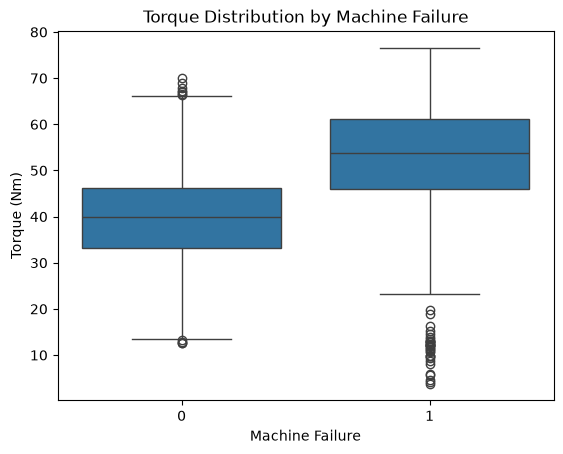

In [36]:
sns.boxplot(data=df, x="Machine failure", y="Torque [Nm]")

plt.title("Torque Distribution by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Torque (Nm)")
plt.show()

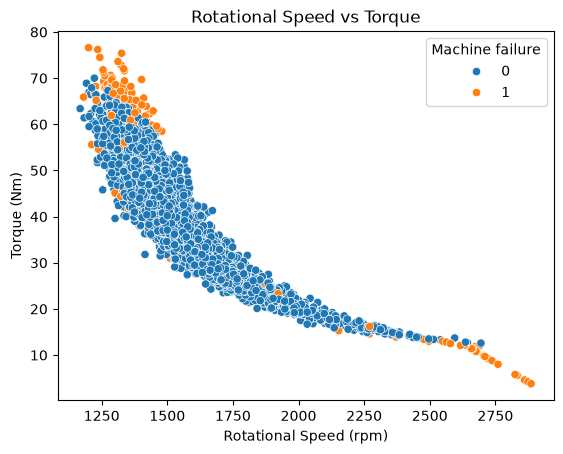

In [37]:
sns.scatterplot(
    data=df,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Machine failure"
)

plt.title("Rotational Speed vs Torque")
plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Torque (Nm)")
plt.show()

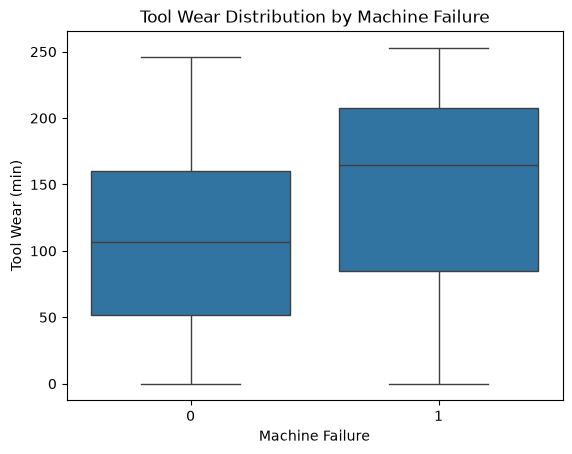

In [38]:
sns.boxplot(data=df, x="Machine failure", y="Tool wear [min]")

plt.title("Tool Wear Distribution by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Tool Wear (min)")
plt.show()

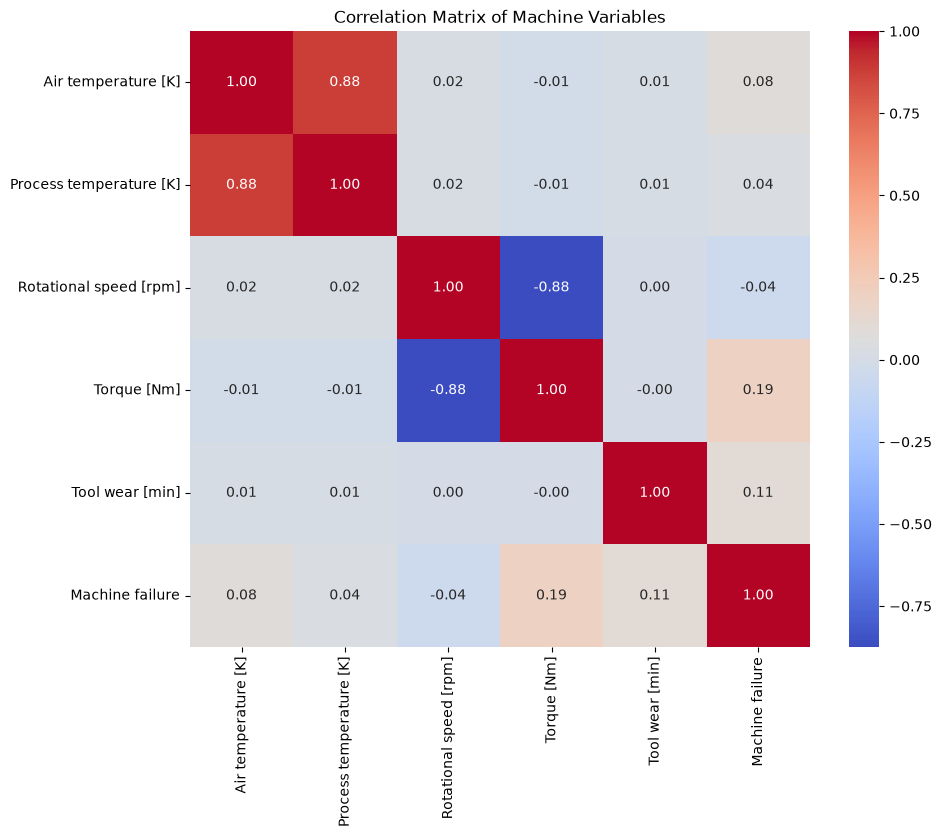

In [39]:
plt.figure(figsize=(10, 8))

correlation = df[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure"
    ]
].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix of Machine Variables")
plt.show()

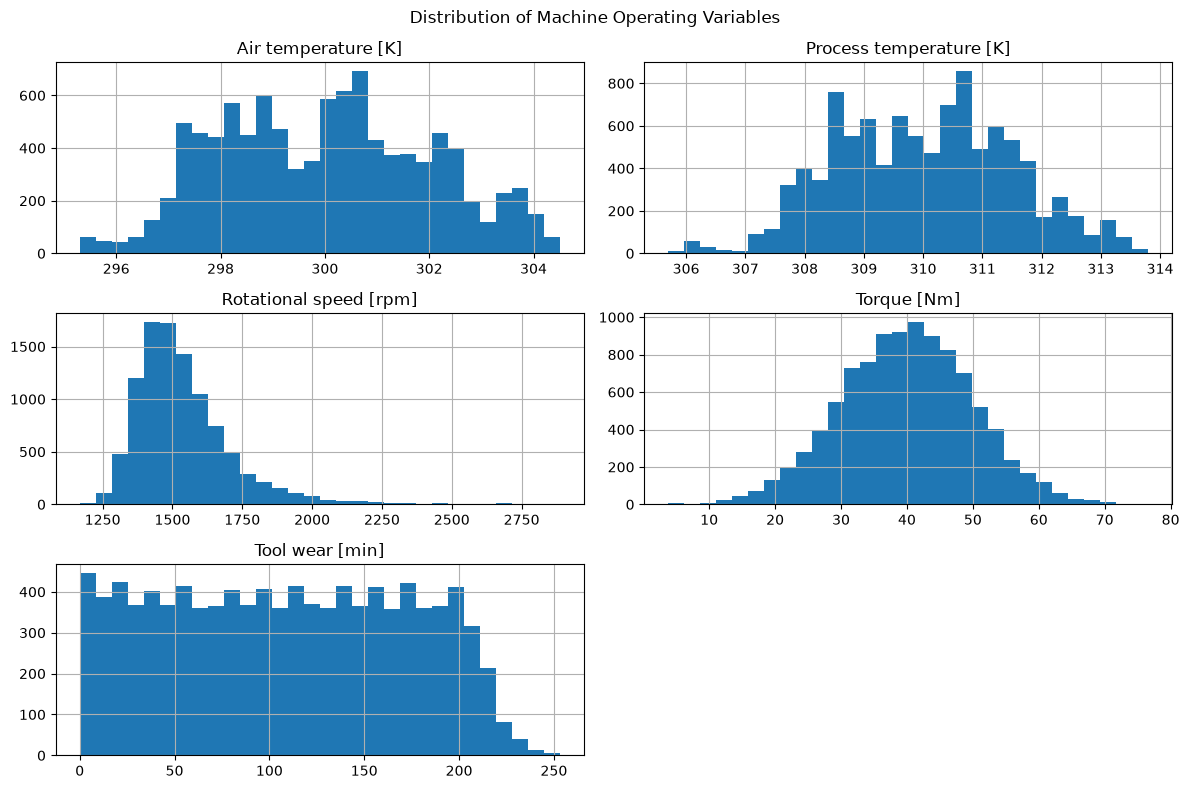

In [40]:
numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df[numerical_features].hist(
    figsize=(12, 8),
    bins=30
)

plt.suptitle("Distribution of Machine Operating Variables")
plt.tight_layout()
plt.show()

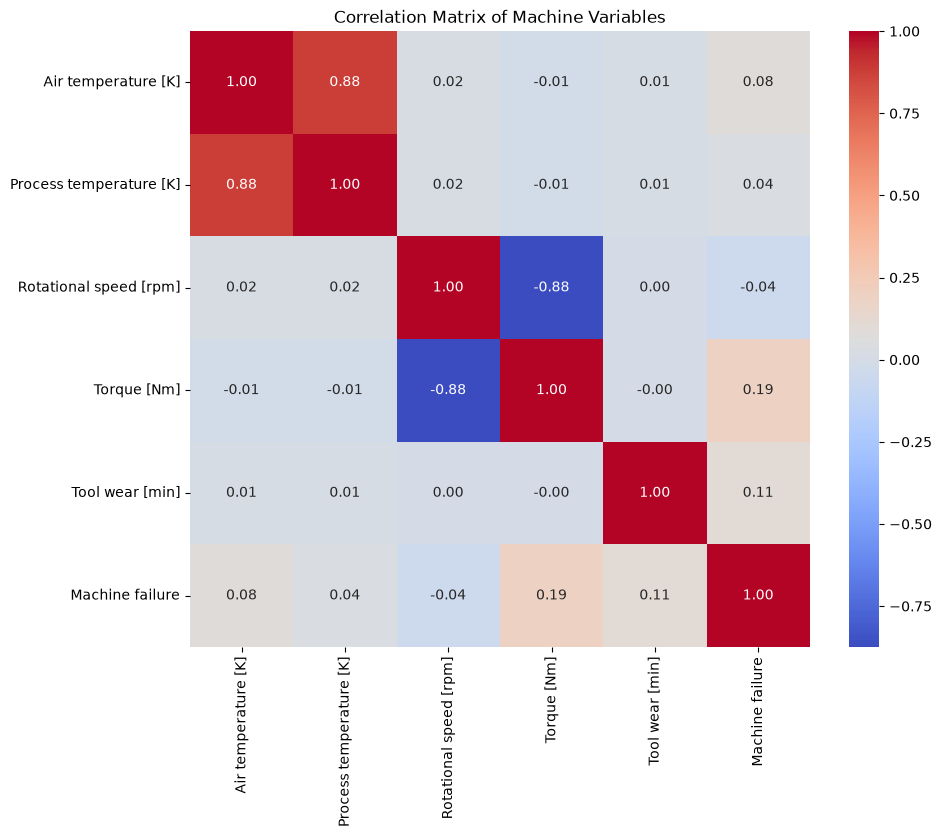

In [41]:
correlation = df[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure"
    ]
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Machine Variables")
plt.show()

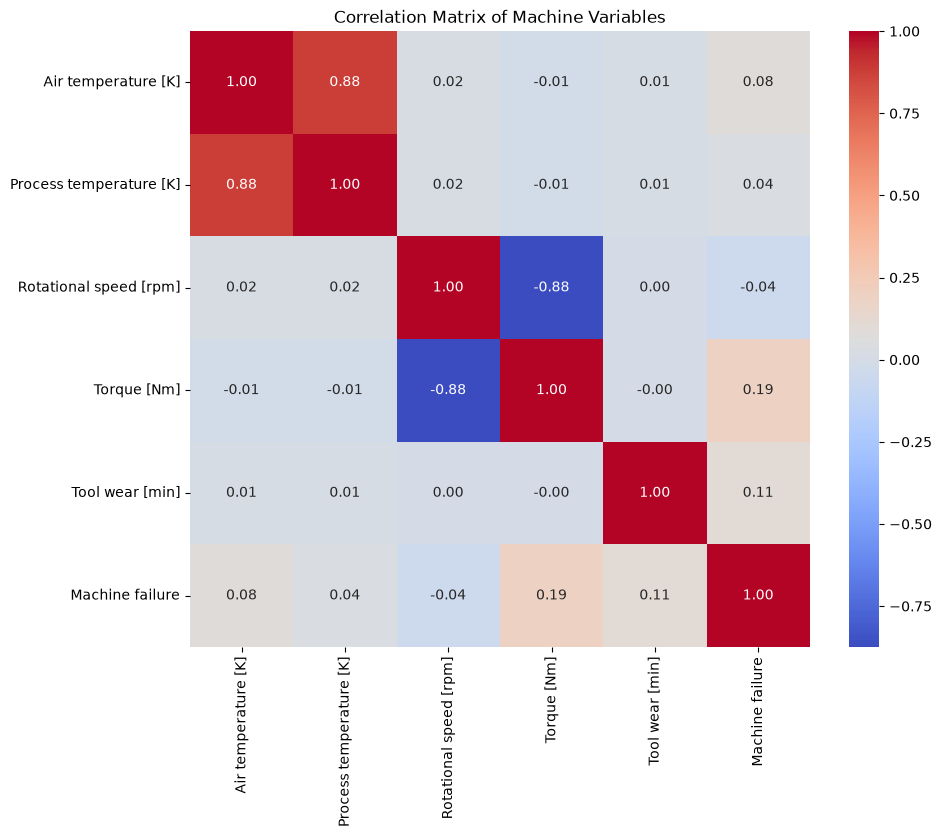

In [42]:
correlation = df[
    [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
        "Tool wear [min]",
        "Machine failure"
    ]
].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Machine Variables")
plt.show()

# Train/Test Split & Preprocessing

In [43]:
features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

X = df[features]
y = df["Machine failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 6)
y shape: (10000,)


In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 6)
X_test : (2000, 6)
y_train: (8000,)
y_test : (2000,)


In [45]:
categorical_features = ["Type"]

numerical_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

Categorical features: ['Type']
Numerical features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Air temperature [K]',
                                  'Process temperature [K]',
                                  'Rotational speed [rpm]', 'Torque [Nm]',
                                  'Tool wear [min]']),
                                ('cat', OneHotEncoder(drop='first'), ['Type'])])


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42))
])

print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Air temperature [K]',
                                                   'Process temperature [K]',
                                                   'Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Type'])])),
                ('classifier', LogisticRegression(random_state=42))])


In [48]:
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [49]:
y_pred = model.predict(X_test)

print("Predictions made.")
print("Sample predictions:", y_pred[:20])
print("Actual values:     ", y_test[:20].values)

Predictions made.
Sample predictions: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Actual values:      [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]


In [50]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9675
Precision: 0.6363636363636364
Recall   : 0.10294117647058823
F1 Score : 0.17721518987341772

Confusion Matrix:
[[1928    4]
 [  61    7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



In [51]:
model_balanced = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(random_state=42, class_weight="balanced"))
])

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall   :", recall_score(y_test, y_pred_balanced))
print("F1 Score :", f1_score(y_test, y_pred_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_balanced))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

Accuracy : 0.8245
Precision: 0.14177215189873418
Recall   : 0.8235294117647058
F1 Score : 0.24190064794816415

Confusion Matrix:
[[1593  339]
 [  12   56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



## Model 2 — Random Forest Classifier

Logistic Regression was established as the baseline classification model, although the balanced version achieved substantially higher recall, its precision remained low, resulting in a high number of false positive predictions.
To investigate whether a nonlinear model can better capture relationships between the machine operating variables, a Random Forest Classifier will be trained and evaluated.

Random Forest was selected because it can model nonlinear relationships and feature 
interactions without requiring the same linear assumptions as Logistic Regression.

In [52]:
from sklearn.ensemble import RandomForestClassifier

model_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.981
Precision: 0.734375
Recall   : 0.6911764705882353
F1 Score : 0.7121212121212122

Confusion Matrix:
[[1915   17]
 [  21   47]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.73      0.69      0.71        68

    accuracy                           0.98      2000
   macro avg       0.86      0.84      0.85      2000
weighted avg       0.98      0.98      0.98      2000



## Hyperparameter Tuning — Random Forest

The initial Random Forest model produced substantially better results than the Logistic Regression baseline. Hyperparameter tuning will therefore be performed to determine whether the model's performance can be improved by adjusting its configuration.

The main hyperparameters considered are the number of trees, tree depth, minimum samples required for a split, minimum samples required at a leaf, and the number of features considered at each split.

RandomizedSearchCV will be used to efficiently explore different combinations using stratified cross-validation.

In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=model_rf,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best F1 (cross-val):", grid_search.best_score_)

Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
Best F1 (cross-val): 0.6973243165476175


In [54]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall   :", recall_score(y_test, y_pred_best))
print("F1 Score :", f1_score(y_test, y_pred_best))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))

Accuracy : 0.982
Precision: 0.75
Recall   : 0.7058823529411765
F1 Score : 0.7272727272727273

Confusion Matrix:
[[1916   16]
 [  20   48]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.75      0.71      0.73        68

    accuracy                           0.98      2000
   macro avg       0.87      0.85      0.86      2000
weighted avg       0.98      0.98      0.98      2000



In [55]:
from sklearn.metrics import roc_auc_score

y_proba_best = best_rf.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba_best)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9638023687735965


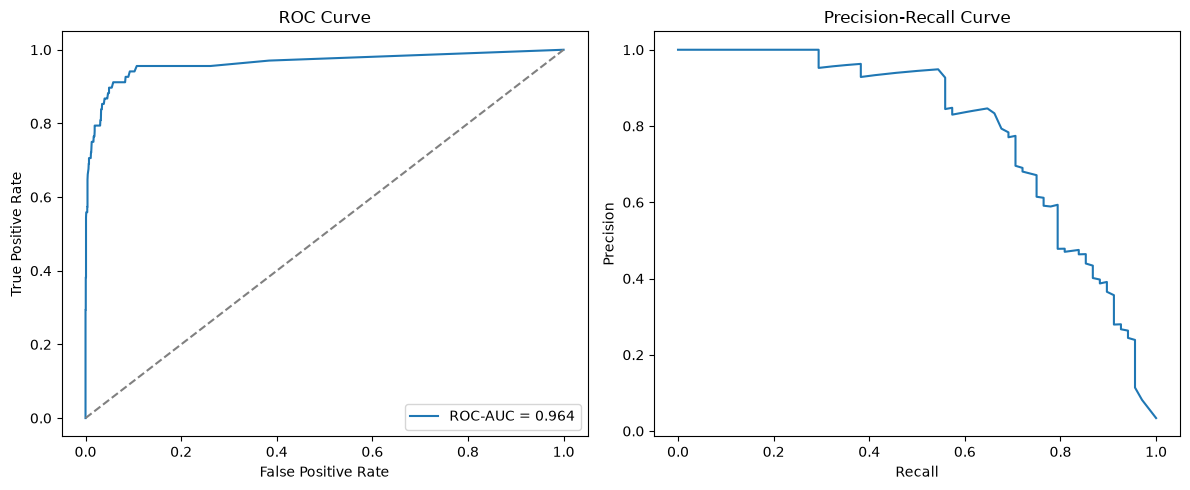

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba_best)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_proba_best)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(recall_vals, precision_vals)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()

In [57]:
import numpy as np

f1_scores = 2 * (precision_vals * recall_vals) / (precision_vals + recall_vals + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = pr_thresholds[best_idx]

print("Best threshold (max F1):", best_threshold)
print("Precision at this threshold:", precision_vals[best_idx])
print("Recall at this threshold:", recall_vals[best_idx])
print("F1 at this threshold:", f1_scores[best_idx])

Best threshold (max F1): 0.525
Precision at this threshold: 0.7741935483870968
Recall at this threshold: 0.7058823529411765
F1 at this threshold: 0.7384615379626036


In [58]:
y_pred_optimal = (y_proba_best >= best_threshold).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred_optimal))
print("Precision:", precision_score(y_test, y_pred_optimal))
print("Recall   :", recall_score(y_test, y_pred_optimal))
print("F1 Score :", f1_score(y_test, y_pred_optimal))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))

Accuracy : 0.983
Precision: 0.7741935483870968
Recall   : 0.7058823529411765
F1 Score : 0.7384615384615385

Confusion Matrix:
[[1918   14]
 [  20   48]]


In [59]:
importances = best_rf.named_steps["classifier"].feature_importances_

feature_names = (
    numerical_features +
    list(best_rf.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features))
)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

                   Feature  Importance
3              Torque [Nm]    0.322362
2   Rotational speed [rpm]    0.286201
4          Tool wear [min]    0.213284
0      Air temperature [K]    0.098706
1  Process temperature [K]    0.063921
5                   Type_L    0.009123
6                   Type_M    0.006403


In [60]:
results_df = X_test.copy()
results_df["Actual"] = y_test.values
results_df["Predicted"] = y_pred_optimal
results_df["Probability"] = y_proba_best

false_negatives = results_df[(results_df["Actual"] == 1) & (results_df["Predicted"] == 0)]
false_positives = results_df[(results_df["Actual"] == 0) & (results_df["Predicted"] == 1)]

print("False Negatives (missed failures):", len(false_negatives))
print(false_negatives)

print("\nFalse Positives (false alarms):", len(false_positives))
print(false_positives)

False Negatives (missed failures): 20
     Type  Air temperature [K]  Process temperature [K]  \
4851    L                303.7                    312.1   
4632    M                302.9                    311.2   
7884    L                300.8                    312.4   
9174    L                297.8                    308.9   
3806    M                302.3                    310.9   
2671    M                299.7                    309.3   
926     L                295.6                    306.1   
2864    H                300.6                    309.4   
4307    L                301.4                    309.9   
3695    L                302.2                    311.3   
1833    L                297.8                    307.3   
4720    M                303.4                    311.7   
7087    L                300.6                    310.3   
2941    M                300.7                    309.6   
9015    L                297.2                    308.1   
4778    H         

In [61]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (unweighted)",
        "Logistic Regression (balanced)",
        "Random Forest (default)",
        "Random Forest (tuned, threshold=0.5)",
        "Random Forest (tuned, threshold=0.525)"
    ],
    "Accuracy": [0.9675, 0.8245, 0.981, 0.982, 0.983],
    "Precision": [0.6364, 0.1418, 0.7344, 0.75, 0.7742],
    "Recall": [0.1029, 0.8235, 0.6912, 0.7059, 0.7059],
    "F1 Score": [0.1772, 0.2419, 0.7121, 0.7273, 0.7385],
    "ROC-AUC": [None, None, None, None, 0.9638]
})

print(comparison_df)

                                    Model  Accuracy  Precision  Recall  \
0        Logistic Regression (unweighted)    0.9675     0.6364  0.1029   
1          Logistic Regression (balanced)    0.8245     0.1418  0.8235   
2                 Random Forest (default)    0.9810     0.7344  0.6912   
3    Random Forest (tuned, threshold=0.5)    0.9820     0.7500  0.7059   
4  Random Forest (tuned, threshold=0.525)    0.9830     0.7742  0.7059   

   F1 Score  ROC-AUC  
0    0.1772      NaN  
1    0.2419      NaN  
2    0.7121      NaN  
3    0.7273      NaN  
4    0.7385   0.9638  


## Final Model Selection

**Chosen model:** Random Forest (tuned, threshold = 0.525)

**Why:**
- Highest F1 score (0.7385) among all models tested — the best balance between catching failures and avoiding false alarms
- Highest precision (0.7742) among viable candidates, with recall (0.7059) still well above both Logistic Regression variants
- Strong ROC-AUC (0.9638), confirming the model ranks failure risk reliably across thresholds, not just at one arbitrary cutoff
- Catches 48 of 68 real failures (71%) while only raising 14 false alarms out of 1,932 healthy machines — a practical, deployable trade-off for predictive maintenance
- Hyperparameter tuning (`n_estimators=200`, `max_depth=None`, `min_samples_leaf=1`) and threshold optimization (0.525 vs default 0.5) both delivered small, consistent improvements with no downside

**Rejected alternatives:**
- Logistic Regression (unweighted): high accuracy but recall of only 10% — fails at the actual task of catching failures
- Logistic Regression (balanced): recall improved to 82%, but precision collapsed to 14% — over 300 false alarms, impractical for deployment
- Random Forest (default, untuned): solid baseline, but tuning and threshold optimization improved it further at no cost

In [62]:
import joblib

joblib.dump(best_rf, "final_model.pkl")
joblib.dump(best_threshold, "final_threshold.pkl")

print("Model and threshold saved.")

Model and threshold saved.


In [63]:
import joblib

loaded_model = joblib.load("final_model.pkl")
loaded_threshold = joblib.load("final_threshold.pkl")

# Simulate fresh predictions using only the saved artifacts
y_proba_loaded = loaded_model.predict_proba(X_test)[:, 1]
y_pred_loaded = (y_proba_loaded >= loaded_threshold).astype(int)

print("Loaded threshold:", loaded_threshold)
print("Accuracy :", accuracy_score(y_test, y_pred_loaded))
print("Precision:", precision_score(y_test, y_pred_loaded))
print("Recall   :", recall_score(y_test, y_pred_loaded))
print("F1 Score :", f1_score(y_test, y_pred_loaded))

Loaded threshold: 0.525
Accuracy : 0.983
Precision: 0.7741935483870968
Recall   : 0.7058823529411765
F1 Score : 0.7384615384615385


# Task 2  Advanced Machine Learning & Model Optimization

## 1. Feature Engineering

In this stage, additional features are created from the existing machine operating variables based on patterns identified during exploratory data analysis and the physical relationships between machine parameters.

The purpose is to determine whether these engineered features can improve the prediction of machine failure.

In [64]:
import pandas as pd

df = pd.read_csv("../data/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [65]:
df_fe = df.copy()

df_fe["Temperature Difference [K]"] = (
    df_fe["Process temperature [K]"] - df_fe["Air temperature [K]"]
)

df_fe["Mechanical Power Proxy"] = (
    df_fe["Torque [Nm]"] * df_fe["Rotational speed [rpm]"]
)

df_fe["Temperature Ratio"] = (
    df_fe["Process temperature [K]"] / df_fe["Air temperature [K]"]
)

df_fe["Torque Speed Ratio"] = (
    df_fe["Torque [Nm]"] / df_fe["Rotational speed [rpm]"]
)

df_fe["Tool Wear Category"] = pd.cut(
    df_fe["Tool wear [min]"],
    bins=[-1, 50, 150, 250],
    labels=["Low", "Medium", "High"]
)

df_fe.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature Difference [K],Mechanical Power Proxy,Temperature Ratio,Torque Speed Ratio,Tool Wear Category
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,1.035223,0.027595,Low
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,1.035211,0.032884,Low
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,1.034888,0.032977,Low
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,1.034876,0.027565,Low
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,1.035211,0.028409,Low


In [66]:
df. shape

(10000, 14)

In [67]:
print("df shape:", df.shape)
print("df_fe shape:", df_fe.shape)

df shape: (10000, 14)
df_fe shape: (10000, 19)


In [68]:
original_features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

engineered_features = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Mechanical Power Proxy",
    "Temperature Ratio",
    "Torque Speed Ratio",
    "Tool Wear Category"
]

X_fe = df_fe[engineered_features]
y_fe = df_fe["Machine failure"]

print("X_fe:", X_fe.shape)
print("y_fe:", y_fe.shape)

X_fe: (10000, 11)
y_fe: (10000,)


In [69]:
from sklearn.model_selection import train_test_split

In [70]:
X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.20,
    random_state=42,
    stratify=y_fe
)

print("X_train:", X_train_fe.shape)
print("X_test :", X_test_fe.shape)
print("y_train:", y_train_fe.shape)
print("y_test :", y_test_fe.shape)

X_train: (8000, 11)
X_test : (2000, 11)
y_train: (8000,)
y_test : (2000,)


In [71]:
categorical_features_fe = [
    "Type",
    "Tool Wear Category"
]

numerical_features_fe = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Temperature Difference [K]",
    "Mechanical Power Proxy",
    "Temperature Ratio",
    "Torque Speed Ratio"
]

preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_fe
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features_fe
        )
    ]
)

In [72]:
rf_fe = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_fe.fit(X_train_fe, y_train_fe)

print("Feature-engineered Random Forest trained.")

Feature-engineered Random Forest trained.


In [73]:
y_pred_fe = rf_fe.predict(X_test_fe)

print("Accuracy :", accuracy_score(y_test_fe, y_pred_fe))
print("Precision:", precision_score(y_test_fe, y_pred_fe))
print("Recall   :", recall_score(y_test_fe, y_pred_fe))
print("F1 Score :", f1_score(y_test_fe, y_pred_fe))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_fe, y_pred_fe))

print("\nClassification Report:")
print(classification_report(y_test_fe, y_pred_fe))

Accuracy : 0.991
Precision: 0.9464285714285714
Recall   : 0.7794117647058824
F1 Score : 0.8548387096774194

Confusion Matrix:
[[1929    3]
 [  15   53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.95      0.78      0.85        68

    accuracy                           0.99      2000
   macro avg       0.97      0.89      0.93      2000
weighted avg       0.99      0.99      0.99      2000



In [74]:
#trained Random Forest
rf_classifier = rf_fe.named_steps["classifier"]

#preprocessing component
preprocessor = rf_fe.named_steps["preprocessor"]

#feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

#Random Forest feature importance
importances = rf_classifier.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
6,num__Mechanical Power Proxy,0.205157
2,num__Rotational speed [rpm],0.156218
3,num__Torque [Nm],0.141474
8,num__Torque Speed Ratio,0.129246
4,num__Tool wear [min],0.119456
7,num__Temperature Ratio,0.080667
5,num__Temperature Difference [K],0.070416
0,num__Air temperature [K],0.034395
1,num__Process temperature [K],0.031393
9,cat__Type_L,0.010812


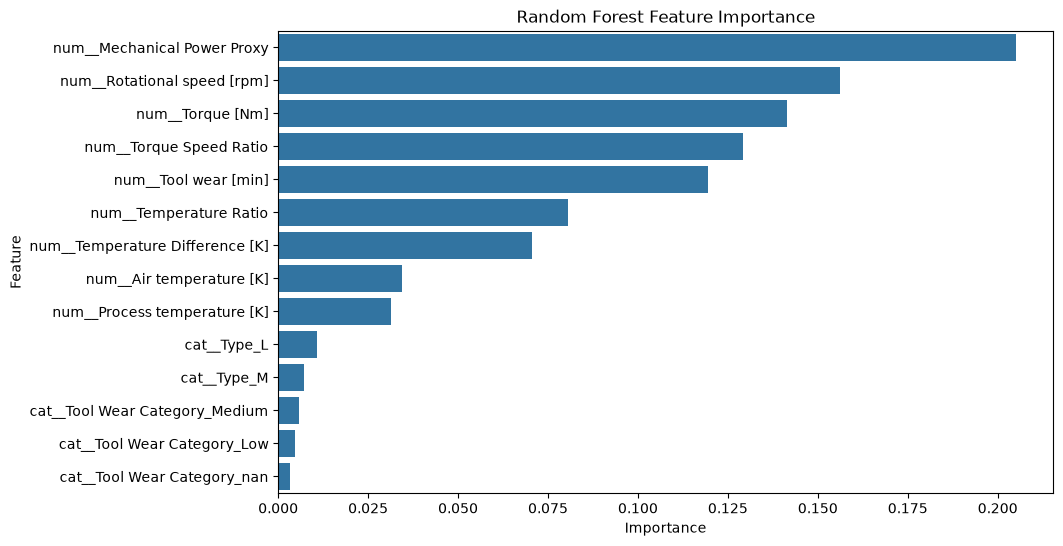

In [75]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [76]:
selected_features = [
    "Type",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Mechanical Power Proxy",
    "Torque Speed Ratio",
    "Temperature Ratio",
    "Temperature Difference [K]"
]

X_selected = df_fe[selected_features]
y_selected = df_fe["Machine failure"]

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y_selected,
    test_size=0.20,
    random_state=42,
    stratify=y_selected
)

print("X_selected:", X_selected.shape)
print("X_train_sel:", X_train_sel.shape)
print("X_test_sel :", X_test_sel.shape)

X_selected: (10000, 8)
X_train_sel: (8000, 8)
X_test_sel : (2000, 8)


In [77]:
categorical_selected = ["Type"]

numerical_selected = [
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Mechanical Power Proxy",
    "Torque Speed Ratio",
    "Temperature Ratio",
    "Temperature Difference [K]"
]

preprocessor_selected = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_selected
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_selected
        )
    ]
)

rf_selected = Pipeline(steps=[
    ("preprocessor", preprocessor_selected),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

rf_selected.fit(X_train_sel, y_train_sel)

y_pred_selected = rf_selected.predict(X_test_sel)

print("Accuracy :", accuracy_score(y_test_sel, y_pred_selected))
print("Precision:", precision_score(y_test_sel, y_pred_selected))
print("Recall   :", recall_score(y_test_sel, y_pred_selected))
print("F1 Score :", f1_score(y_test_sel, y_pred_selected))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_sel, y_pred_selected))

Accuracy : 0.9925
Precision: 0.9491525423728814
Recall   : 0.8235294117647058
F1 Score : 0.8818897637795275

Confusion Matrix:
[[1929    3]
 [  12   56]]


* Hyperparameter tuning on the selected features

In [78]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf_selected,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sel, y_train_sel)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1:")
print(grid_search.best_score_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 100}

Best cross-validation F1:
0.8217213452299245


In [79]:
best_rf = grid_search.best_estimator_

y_pred_tuned = best_rf.predict(X_test_sel)

print("Accuracy :", accuracy_score(y_test_sel, y_pred_tuned))
print("Precision:", precision_score(y_test_sel, y_pred_tuned))
print("Recall   :", recall_score(y_test_sel, y_pred_tuned))
print("F1 Score :", f1_score(y_test_sel, y_pred_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_sel, y_pred_tuned))

print("\nClassification Report:")
print(classification_report(y_test_sel, y_pred_tuned))

Accuracy : 0.992
Precision: 0.9482758620689655
Recall   : 0.8088235294117647
F1 Score : 0.873015873015873

Confusion Matrix:
[[1929    3]
 [  13   55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1932
           1       0.95      0.81      0.87        68

    accuracy                           0.99      2000
   macro avg       0.97      0.90      0.93      2000
weighted avg       0.99      0.99      0.99      2000



In [80]:
from sklearn.inspection import permutation_importance

In [84]:
perm_result = permutation_importance(
    rf_selected,
    X_test_sel,
    y_test_sel,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [86]:
permutation_df = pd.DataFrame({
    "Feature": X_test_sel.columns,
    "Importance Mean": perm_result.importances_mean,
    "Importance Std": perm_result.importances_std
}).sort_values(
    by="Importance Mean",
    ascending=False
)

permutation_df

,Feature,Importance Mean,Importance Std
1,Rotational speed [rpm],0.386319,0.022855
4,Mechanical Power Proxy,0.256013,0.011417
6,Temperature Ratio,0.248340,0.017908
7,Temperature Difference [K],0.213420,0.017533
3,Tool wear [min],0.208532,0.017499
2,Torque [Nm],0.060376,0.010061
0,Type,0.043949,0.017819
5,Torque Speed Ratio,0.043656,0.008778


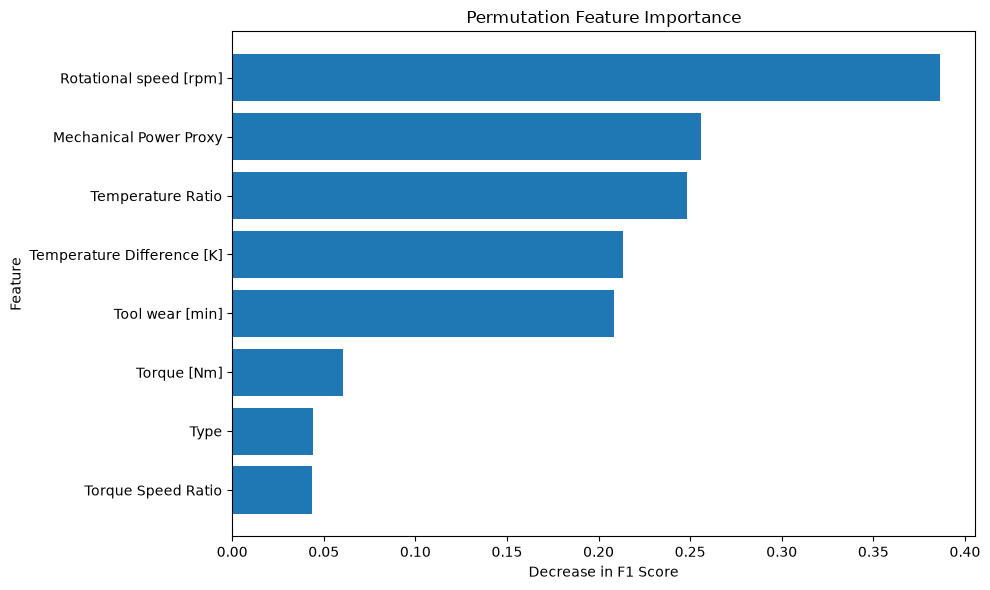

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    permutation_df["Feature"],
    permutation_df["Importance Mean"]
)

plt.xlabel("Decrease in F1 Score")
plt.ylabel("Feature")

plt.title(
    "Permutation Feature Importance"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Permutation importance was used to provide an additional model explainability analysis. The technique measures the importance of each feature by randomly shuffling its values and observing the resulting decrease in model performance. In this analysis, the F1 score was used as the evaluation metric because the machine failure dataset is imbalanced.
The results showed that Rotational Speed [rpm] was the most influential feature, with an average decrease in F1 score of approximately 0.386 when the feature was randomly permuted.
Several engineered features also demonstrated high importance. Mechanical Power Proxy, Temperature Ratio, and Temperature Difference [K] produced substantial decreases in F1 score when permuted. This indicates that the feature engineering process successfully created meaningful variables that contributed useful predictive information to the model.
Tool Wear [min] was also an important predictor, which is consistent with the expectation that increasing machine component wear may be associated with machine failure.
In contrast, Type and Torque Speed Ratio had the lowest permutation importance values. However, they were retained in the selected model because the feature selection process and overall model performance indicated that they could still provide useful information when combined with other features.

In [88]:
y_proba_selected = rf_selected.predict_proba(
    X_test_sel
)[:, 1]

In [89]:
from sklearn.metrics import roc_auc_score

roc_auc_selected = roc_auc_score(
    y_test_sel,
    y_proba_selected
)

print(
    "ROC-AUC Score:",
    roc_auc_selected
)

ROC-AUC Score: 0.9678594263792475


In [90]:
print(f"ROC-AUC Score: {roc_auc_selected:.4f}")

ROC-AUC Score: 0.9679


The selected-feature Random Forest model achieved an ROC-AUC score of 0.9679. This indicates that the model has a strong ability to distinguish between machine failure and non-failure observations. 

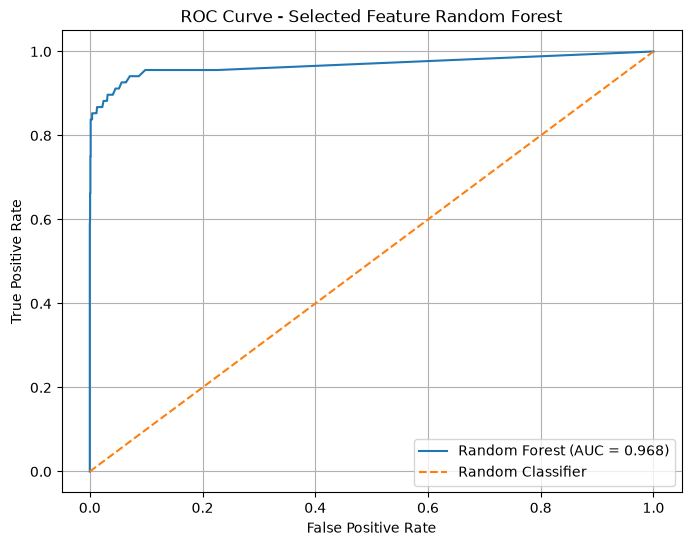

In [92]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test_sel,
    y_proba_selected
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc_selected:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Selected Feature Random Forest")

plt.legend()
plt.grid()

plt.show()

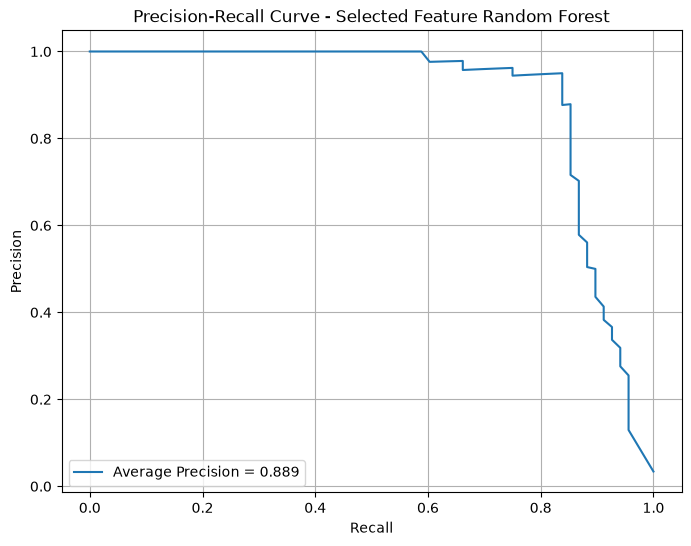

Average Precision: 0.8887172966479563


In [93]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(
    y_test_sel,
    y_proba_selected
)

average_precision = average_precision_score(
    y_test_sel,
    y_proba_selected
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"Average Precision = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Selected Feature Random Forest")

plt.legend()
plt.grid()

plt.show()

print(
    "Average Precision:",
    average_precision
)

The ROC curve demonstrates strong discriminative performance for the selected feature Random Forest model. The model achieved an ROC-AUC score of 0.9679, indicating a high ability to distinguish between machine failure and non failure observations across different classification thresholds. The ROC curve remains close to the top left corner of the graph and performs substantially better than the random classifier baseline.
The Precision Recall curve provides an important evaluation for this imbalanced machine failure dataset. The selected feature Random Forest model achieved an Average Precision score of 0.8887. The curve shows that the model maintains high precision across a wide range of recall values. However, precision decreases as recall approaches 1.0, demonstrating the trade off between detecting a larger proportion of machine failures and increasing the number of false positive predictions.

In [94]:
comparison_df = pd.DataFrame({
    "Model": [
        "Task 1 Final Model",
        "Feature Engineered Model",
        "Selected Feature Model",
        "Tuned Model"
    ],

    "Accuracy": [
        0.9830,
        0.9910,
        0.9925,
        0.9920
    ],

    "Precision": [
        0.7742,
        0.9464,
        0.9492,
        0.9483
    ],

    "Recall": [
        0.7059,
        0.7794,
        0.8235,
        0.8088
    ],

    "F1 Score": [
        0.7385,
        0.8548,
        0.8819,
        0.8730
    ],

    "ROC-AUC": [
        0.9638,
        None,
        0.9679,
        None
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Task 1 Final Model,0.9830,0.7742,0.7059,0.7385,0.9638
1,Feature Engineered Model,0.9910,0.9464,0.7794,0.8548,NaN
2,Selected Feature Model,0.9925,0.9492,0.8235,0.8819,0.9679
3,Tuned Model,0.9920,0.9483,0.8088,0.8730,NaN


In [95]:
comparison_df = pd.DataFrame({
    "Model": [
        "Task 1 Final Model",
        "Feature Engineered Model",
        "Selected Feature Model",
        "Tuned Model"
    ],

    "Accuracy": [
        0.9830,
        0.9910,
        0.9925,
        0.9920
    ],

    "Precision": [
        0.7742,
        0.9464,
        0.9492,
        0.9483
    ],

    "Recall": [
        0.7059,
        0.7794,
        0.8235,
        0.8088
    ],

    "F1 Score": [
        0.7385,
        0.8548,
        0.8819,
        0.8730
    ],

    "ROC-AUC": [
        0.9638,
        None,
        0.9679,
        None
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Task 1 Final Model,0.9830,0.7742,0.7059,0.7385,0.9638
1,Feature Engineered Model,0.9910,0.9464,0.7794,0.8548,NaN
2,Selected Feature Model,0.9925,0.9492,0.8235,0.8819,0.9679
3,Tuned Model,0.9920,0.9483,0.8088,0.8730,NaN


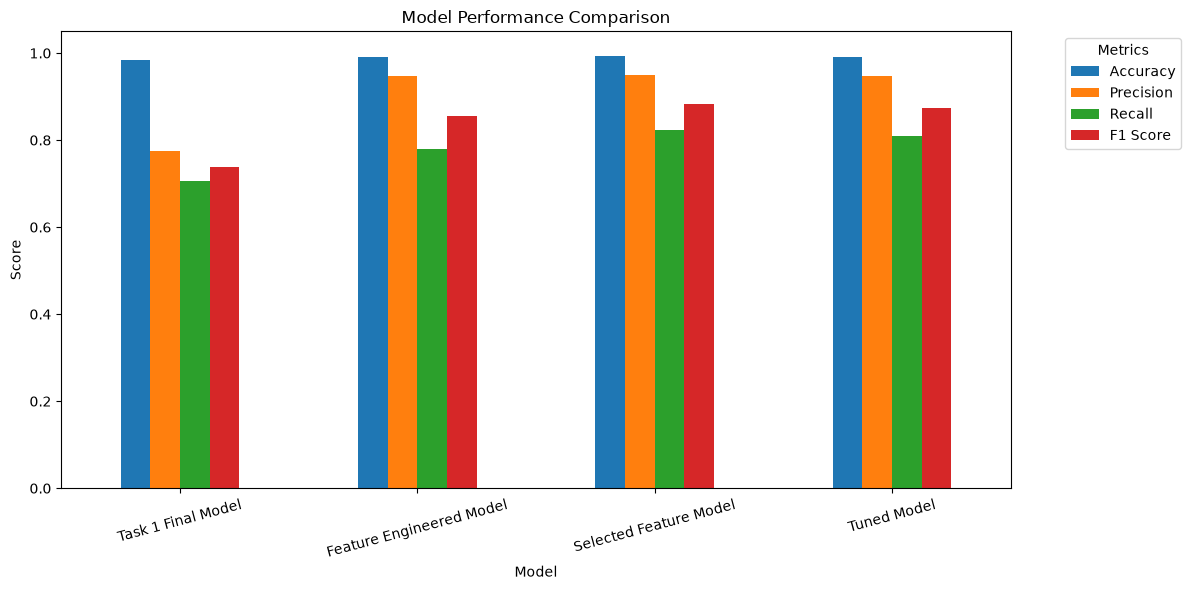

In [96]:
import matplotlib.pyplot as plt

plot_df = comparison_df.set_index("Model")

ax = plot_df[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=15)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Final Model Selection

The final model was selected based primarily on the F1 score because the machine failure dataset is imbalanced. Accuracy alone was not considered sufficient because a model could achieve high accuracy while failing to identify a significant proportion of machine failures.

The Task 2 Selected Feature Random Forest model achieved the strongest overall performance:

- Accuracy: 0.9925
- Precision: 0.9492
- Recall: 0.8235
- F1 Score: 0.8819
- ROC-AUC: 0.9679
- Average Precision: 0.8887

Although hyperparameter optimization was performed using GridSearchCV, the tuned model achieved a slightly lower F1 score of 0.8730 on the independent test set. Therefore, the Selected Feature Random Forest model was chosen as the final model because it achieved the highest F1 score and the best overall balance between precision and recall.

The selected-feature model also uses fewer input features than the full feature-engineered model, reducing model complexity while improving predictive performance. This suggests that feature selection successfully removed less useful information and retained the most relevant predictors for machine failure prediction.

In [97]:
rf_selected

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Type','Rotational speed [rpm]','Torque [Nm]',...,'Torque Speed Ratio', 'Temperature Ratio','Temperature Difference [K]']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dr

In [98]:
print(rf_selected)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Rotational speed [rpm]',
                                                   'Torque [Nm]',
                                                   'Tool wear [min]',
                                                   'Mechanical Power Proxy',
                                                   'Torque Speed Ratio',
                                                   'Temperature Ratio',
                                                   'Temperature Difference '
                                                   '[K]']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Type'])])),
                ('classifier',


In [99]:
import joblib

joblib.dump(
    rf_selected,
    "final_machine_failure_model.pkl"
)

print("Final model saved successfully!")

Final model saved successfully!


# Final Technical Conclusion
1. Summary of the Improvements
This Task 2 project built upon the machine failure prediction solution developed in Task 1. The main objective was to improve the machine learning solution through advanced feature engineering, feature selection, hyperparameter optimization, and model explainability techniques.
Several new features were created to capture relationships between the original machine sensor variables:
Temperature Difference [K]
Mechanical Power Proxy
Temperature Ratio
Torque Speed Ratio
Tool Wear Category
These engineered features were designed to provide additional information about machine operating conditions and interactions between important variables.
The feature engineering process was followed by feature importance analysis and feature selection. The original feature-engineered model used a larger set of features, while the selected-feature model used the most relevant predictors.

2. Model Performance Improvements
The results showed a significant improvement from Task 1 to Task 2.
## Model Performance Comparison

| Model | Accuracy | Precision | Recall | F1 Score |
|---|---:|---:|---:|---:|
| Task 1 Final Model | 0.9830 | 0.7742 | 0.7059 | 0.7385 |
| Task 2 Feature Engineered Model | 0.9910 | 0.9464 | 0.7794 | 0.8548 |
| **Task 2 Selected Feature Model** | **0.9925** | **0.9492** | **0.8235** | **0.8819** |
| Task 2 Tuned Model | 0.9920 | 0.9483 | 0.8088 | 0.8730 |
The strongest model was the Task 2 Selected Feature Random Forest model, which achieved an F1 score of 0.8819, compared with 0.7385 for the Task 1 final model.
This represents an absolute F1 score improvement of approximately 0.1434.
The improvement was particularly important because the dataset contains an imbalanced machine failure target. Therefore, the F1 score was considered a more informative metric than accuracy alone because it balances precision and recall.

3. Why Did Performance Improve?

The improved performance was primarily associated with feature engineering and feature selection.
The engineered features captured useful relationships between machine operating variables. For example, the Mechanical Power Proxy combined rotational speed and torque and was identified as an important predictor during model explainability analysis.
Permutation importance also showed that several engineered features contributed substantially to model performance, including:
Mechanical Power Proxy
Temperature Ratio
Temperature Difference [K]
Rotational Speed [rpm] was identified as the most influential feature according to permutation importance.
Feature selection further improved the model by reducing the number of input features from the full engineered feature set to the most useful predictors. The selected-feature model achieved a higher F1 score than the full feature-engineered model.
This suggests that removing less useful features reduced unnecessary model complexity and allowed the model to focus on the strongest predictive signals.

4. Model Explainability

* Two explainability techniques were used:
* Random Forest feature importance
Random Forest feature importance was used to identify features that contributed strongly to the decision-making process of the model.
The results highlighted the importance of:
Mechanical Power Proxy
Rotational Speed
Torque
Torque Speed Ratio
Tool Wear

* Permutation Importance
Permutation importance was also applied using the F1 score as the evaluation metric.
The results showed that Rotational Speed [rpm] had the highest permutation importance. Several engineered features also showed strong contributions to model performance. This provided evidence that the feature engineering process created useful variables and that the model relied on meaningful machine operating characteristics when predicting machine failures.

5. Final Model Evaluation

The selected-feature Random Forest model achieved the following results:
Accuracy: 0.9925
Precision: 0.9492
Recall: 0.8235
F1 Score: 0.8819
ROC-AUC: 0.9679
Average Precision: 0.8887

The ROC-AUC score demonstrated strong ability to distinguish between machine failure and non failure observations.
The Precision Recall Curve was particularly important because the machine failure dataset is imbalanced. The Average Precision score of 0.8887 showed that the model maintained strong precision across a wide range of recall values. However, the Precision Recall analysis also demonstrated the expected trade-off: increasing recall toward very high levels may reduce precision and generate additional false positive predictions.

6. Hyperparameter Optimization

GridSearchCV with 5-fold cross validation was used to optimize the Random Forest model.
The best hyperparameters identified were:
Maximum Depth: 10
Minimum Samples Leaf: 1
Number of Estimators: 100

Although hyperparameter optimization identified the best performing configuration during cross validation, the tuned model achieved a slightly lower F1 score of 0.8730 on the independent test set compared with 0.8819 for the selected feature model. This demonstrates an important machine learning principle: the best hyperparameters identified during cross-validation do not always produce the highest performance on a specific independent test dataset.

7. The Task 2 model showed improved generalization compared with the Task 1 model.

The use of:
Stratified train test splitting
Cross validation
Feature selection
Hyperparameter optimization
Independent test set evaluation

provided a more robust evaluation process.
The selected feature model achieved strong performance on the held out test dataset, including an F1 score of 0.8819 and ROC-AUC of 0.9679.
Although the tuned model did not outperform the selected feature model on the test set, the cross validation process still provided useful information about model stability and helped investigate the relationship between model complexity and generalization.

8. Trade Off Between Performance and Complexity

The results demonstrated that increasing model complexity does not always result in better predictive performance.
The feature engineered model introduced additional variables and improved performance significantly compared with Task 1. However, feature selection further improved the F1 score while reducing the number of features used by the model. Similarly, hyperparameter optimization produced a more constrained Random Forest model but did not outperform the selected feature model on the independent test dataset.
Therefore, the final model was selected based on the best balance between:
Predictive performance
Precision
Recall
Model complexity
Interpretability

The Selected Feature Random Forest model was selected as the final model.
It was selected because it achieved the strongest overall performance:
F1 Score: 0.8819
Accuracy: 0.9925
Precision: 0.9492
Recall: 0.8235
ROC-AUC: 0.9679
Average Precision: 0.8887

The model outperformed both the original model and the hyperparameter tuned model on the independent test dataset.
